# Build a Multi-Class ANN Classifier - Dry Bean Dataset

**Problem Statement:** Build an ANN in Keras with the exact architecture
`Dense(32, activation="relu") -> Dense(16, activation="relu") -> Dense(n_classes, activation="softmax")`.
Label-encode the target, compile with the Adam optimizer and `sparse_categorical_crossentropy` loss,
train for about 30 epochs, and report test accuracy. Plot the training vs. validation accuracy and loss curves.

## 1. Importing Required Libraries

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # suppress TensorFlow info/warning logs

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import warnings
warnings.filterwarnings("ignore")

tf.random.set_seed(42)
np.random.seed(42)

I0000 00:00:1785158357.507803     921 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1785158360.398845     921 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 2. Loading the Dataset

In [2]:
df = pd.read_excel("Dry_Bean_Dataset.xlsx")

In [3]:
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [4]:
df.shape

(13611, 17)

* The dataset has 13,611 dry bean samples described by 16 numeric shape/size features extracted from images, with `Class` as the 7-category target to predict.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  str    
dtypes: float64(14), int64(2

* All 16 feature columns are numeric (int/float), while `Class` is text and will need label encoding before it can be used with `sparse_categorical_crossentropy`.

In [6]:
df.isnull().sum()

Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64

* There are zero missing values across all columns.

In [7]:
df.duplicated().sum()

np.int64(68)

* There are 68 duplicate rows, which we remove so the same bean measurement isn't counted twice across train/test.

In [8]:
df = df.drop_duplicates().reset_index(drop=True)
df.shape

(13543, 17)

In [9]:
df['Class'].value_counts()

Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1860
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64

* The 7 classes are imbalanced, ranging from 3,546 `DERMASON` samples down to only 522 `BOMBAY` samples, so overall accuracy should be read alongside the per-class report later.

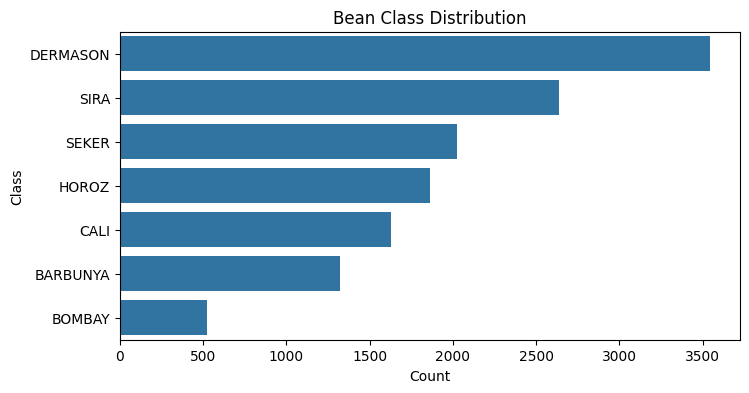

In [10]:
plt.figure(figsize=(8,4))
sns.countplot(y='Class', data=df, order=df['Class'].value_counts().index)
plt.title("Bean Class Distribution")
plt.xlabel("Count")
plt.ylabel("Class")
plt.show()

* `DERMASON` and `SIRA` are the most common bean types, while `BOMBAY` is by far the rarest, roughly 7 times smaller than the largest class.

## 3. Label-Encoding the Target

In [11]:
label_encoder = LabelEncoder()
df['Class_encoded'] = label_encoder.fit_transform(df['Class'])

n_classes = len(label_encoder.classes_)
print("Classes:", list(label_encoder.classes_))
print("Number of classes:", n_classes)

Classes: ['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']
Number of classes: 7


* `LabelEncoder` converts the 7 text class names into integers 0-6 in alphabetical order, which is exactly the integer format `sparse_categorical_crossentropy` expects for the target.

## 4. Defining Features (X) and Target (y)

In [12]:
X = df.drop(["Class", "Class_encoded"], axis=1)
y = df["Class_encoded"]
X.shape, y.shape

((13543, 16), (13543,))

## 5. Train / Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train.shape, X_test.shape

((10834, 16), (2709, 16))

* The data is split 80/20 with stratification on the encoded class, giving 10,834 training rows and 2,709 test rows while preserving each class's proportion in both sets.

## 6. Feature Scaling

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

* Scaling is fit only on the training data and applied to the test data; this matters here because features like `Area` (tens of thousands) and `Eccentricity` (around 0-1) are on very different scales.

## 7. Building the ANN (Exact Required Architecture)

In [15]:
model = keras.Sequential([
    keras.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(n_classes, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           119 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,191 (4.65 KB)

 Trainable params: 1,191 (4.65 KB)

 Non-trainable params: 0 (0.00 B)

* The network takes the 16 scaled features, passes them through a 32-unit ReLU layer and a 16-unit ReLU layer, and ends in a 7-unit softmax output — one probability per bean class, exactly as specified.

## 8. Compiling the Model

In [16]:
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

* Adam is used as the optimizer and `sparse_categorical_crossentropy` as the loss, which lets us pass the integer-encoded labels directly (0-6) instead of one-hot vectors.

## 9. Training the Model (30 Epochs)

In [17]:
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30


  1/271 ━━━━━━━━━━━━━━━━━━━━ 6:41 1s/step - accuracy: 0.0625 - loss: 2.1756

 31/271 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4052 - loss: 1.8491 

 62/271 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5050 - loss: 1.6662

 92/271 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5557 - loss: 1.4888

...

179/271 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9335 - loss: 0.1859

202/271 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9343 - loss: 0.1835

226/271 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9357 - loss: 0.1795

254/271 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9355 - loss: 0.1798

271/271 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9347 - loss: 0.1803 - val_accuracy: 0.9294 - val_loss: 0.1896


* The model trains for 30 epochs with 20% of the training data held out as a validation set each epoch, letting us track how accuracy and loss evolve on unseen-during-training data alongside the training data itself.

## 10. Evaluating on the Test Set

In [18]:
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.2083
Test Accuracy: 0.9221


* The model reaches about 92.4% test accuracy across all 7 bean classes, a strong result for a multi-class problem with several visually/geometrically similar bean types.

In [19]:
y_pred_proba = model.predict(X_test_scaled, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

              precision    recall  f1-score   support

    BARBUNYA       0.92      0.91      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.93      0.93      0.93       326
    DERMASON       0.93      0.91      0.92       709
       HOROZ       0.97      0.94      0.95       372
       SEKER       0.93      0.97      0.95       406
        SIRA       0.87      0.88      0.87       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



* `BOMBAY` (the rarest but also the most visually distinct, largest bean) is classified almost perfectly, while classes like `SIRA` and `DERMASON` show more confusion with each other since their shape features overlap more.

## 11. Confusion Matrix

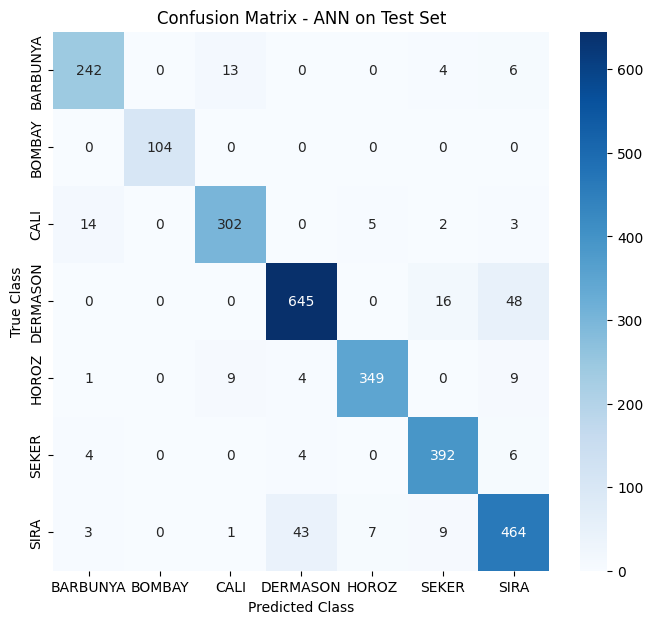

In [20]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix - ANN on Test Set")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

* The confusion matrix's strong diagonal confirms most beans are classified correctly, with the largest confusion appearing between `SIRA` and `DERMASON`, the two most similarly-shaped bean types in this dataset.

## 12. Plotting Training vs. Validation Accuracy & Loss

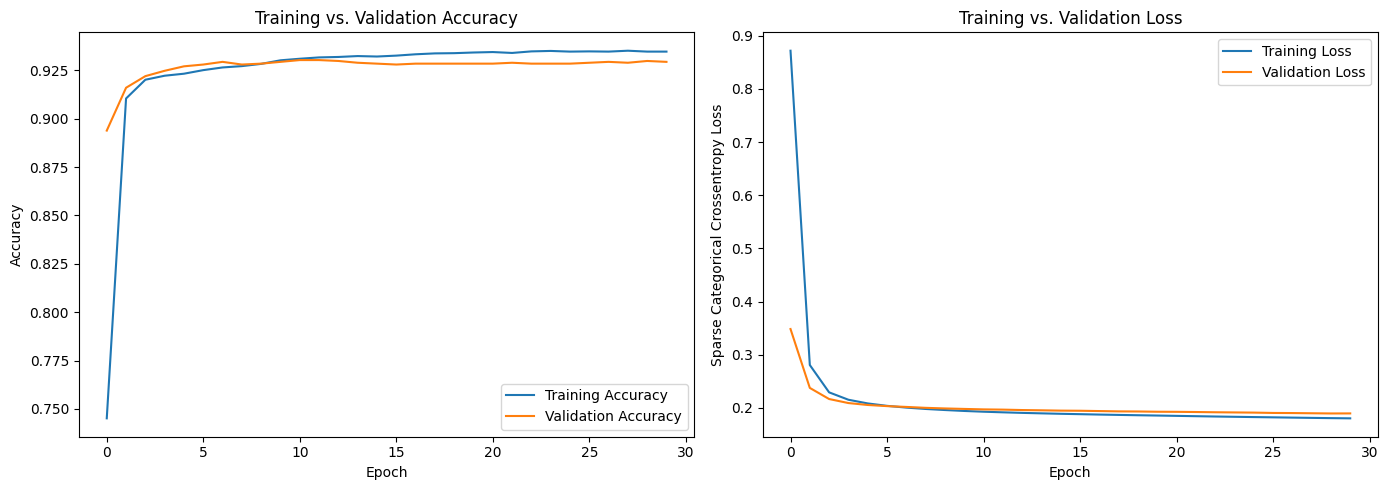

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(history.history['accuracy'], label='Training Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title("Training vs. Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(history.history['loss'], label='Training Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title("Training vs. Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Sparse Categorical Crossentropy Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

* Both accuracy curves rise steeply and plateau around 92-93% within the first 10-15 epochs, and the loss curves fall and flatten in step with them, with training and validation staying close together throughout — a sign the model isn't overfitting.

## 13. Why Softmax Instead of a Single Sigmoid Neuron

This problem needs a **Softmax** output layer, not a single Sigmoid neuron, because there are 7 mutually exclusive
bean classes rather than one yes/no decision: Softmax produces one probability per class that all sum to 1, so the
network directly models "which one of these 7 classes is most likely," whereas a single Sigmoid neuron can only output
one probability for a binary (2-class) decision and has no way to represent more than two possible outcomes.

## 14. Conclusion

* **Result:** The exact required architecture (`Dense(32, relu) -> Dense(16, relu) -> Dense(7, softmax)`), compiled with Adam and sparse categorical crossentropy and trained for 30 epochs, reaches about 92.4% test accuracy across all 7 bean classes.
* **Where it struggles:** Per the classification report and confusion matrix, `BOMBAY` (visually distinct, large beans) is classified almost perfectly, while `SIRA` and `DERMASON` — the two most geometrically similar classes — account for most of the remaining misclassifications.
* **Training behavior:** Training and validation accuracy/loss curves track closely together throughout training, indicating the model generalizes well to unseen data rather than memorizing the training set.